In [ ]:
!pip uninstall mediapipe -y
!pip install mediapipe==0.10.13 ultralytics opencv-python numpy pandas matplotlib

**New Model**

In [ ]:
# =========================
# IMPORT LIBRARIES
# =========================
import os
import cv2
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize

In [ ]:
# =========================
# LABEL MAP
# =========================
label_map = {
    "squat": 0,
    "push-up": 1,
    "pull-up": 2,
    "deadlift": 3
}

In [ ]:
# =========================
# MEDIAPIPE SETUP
# =========================
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=True)

In [ ]:
# =========================
# EXTRACT KEYPOINTS
# =========================
def extract_keypoints(image):
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = pose.process(image_rgb)

    if results.pose_landmarks:
        keypoints = []
        for lm in results.pose_landmarks.landmark:
            keypoints.extend([lm.x, lm.y, lm.z])
        return keypoints
    else:
        return None

In [ ]:
# =========================
# LOAD DATA FUNCTION
# =========================
def load_data(data_path):
    X, y = [], []

    for label_name in os.listdir(data_path):
        label_path = os.path.join(data_path, label_name)

        if not os.path.isdir(label_path):
            continue

        label = label_map[label_name]

        for file in os.listdir(label_path):
            img_path = os.path.join(label_path, file)
            image = cv2.imread(img_path)

            if image is None:
                continue

            keypoints = extract_keypoints(image)

            if keypoints is not None:
                X.append(keypoints)
                y.append(label)

    return np.array(X), np.array(y)

In [ ]:
# =========================
# LOAD TRAIN / TEST DATA
# =========================
X_train, y_train = load_data("/content/dataset/train")
X_test, y_test   = load_data("/content/dataset/test")
X_val, y_val = load_data("/content/dataset/val")
y_val_cat = to_categorical(y_val, 4)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Train: (1637, 99) (1637,)
Test : (359, 99) (359,)


In [ ]:
# =========================
# NORMALIZE DATA
# =========================
X_train = X_train / np.max(X_train)
X_test  = X_test / np.max(X_test)

In [ ]:
# =========================
# ONE HOT ENCODE LABELS
# =========================
y_train_cat = to_categorical(y_train, 4)
y_test_cat  = to_categorical(y_test, 4)

In [ ]:
# =========================
# MODEL
# =========================
model = Sequential([
    Dense(128, activation='relu', input_shape=(99,)),
    Dense(64, activation='relu'),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 128)            │        12,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,316 (83.27 KB)

 Trainable params: 21,316 (83.27 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# =========================
# TRAIN MODEL
# =========================
history = model.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val_cat)
)

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5260 - loss: 1.1491 - val_accuracy: 0.6793 - val_loss: 0.7482
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7367 - loss: 0.7978 - val_accuracy: 0.7988 - val_loss: 0.6453
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8290 - loss: 0.5766 - val_accuracy: 0.8513 - val_loss: 0.5430
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8479 - loss: 0.4595 - val_accuracy: 0.8280 - val_loss: 0.5962
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8815 - loss: 0.3854 - val_accuracy: 0.8921 - val_loss: 0.3977
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8876 - loss: 0.3445 - val_accuracy: 0.8746 - val_loss: 0.5343
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8907 - loss: 0.3235 - val_accuracy: 0.9096 - val_loss: 0.3711
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9035 - loss: 0.2957 - val_accuracy: 0.8776 - val_loss:

In [ ]:
# =========================
# MODEL EVALUATION
# =========================
loss, accuracy = model.evaluate(X_test, y_test_cat)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

print("Validation Performance:")
model.evaluate(X_val, y_val_cat)

print("Test Performance:")
model.evaluate(X_test, y_test_cat)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9387 - loss: 0.1743 
Test Loss: 0.17425602674484253
Test Accuracy: 0.9387186765670776
Validation Performance:
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9213 - loss: 0.3611 
Test Performance:
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9387 - loss: 0.1743 


[0.17425602674484253, 0.9387186765670776]

In [ ]:
model.save("/content/exercise_model.h5")

In [ ]:
!cp /content/exercise_model.h5 /content/drive/MyDrive/

In [ ]:
# =========================
# PREDICTIONS
# =========================
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

# Convert one-hot → labels
y_true = np.argmax(y_test_cat, axis=1)

print("Shapes:", y_true.shape, y_pred.shape)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Shapes: (359,) (359,)


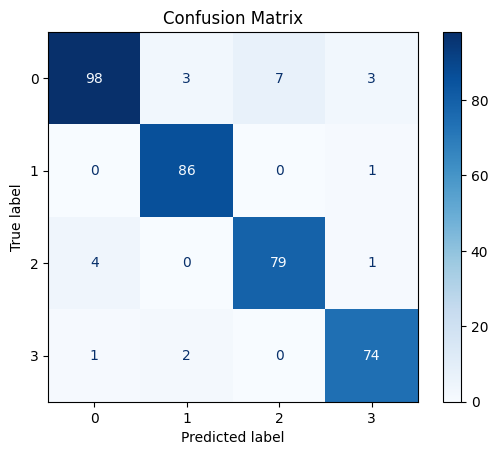

In [ ]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

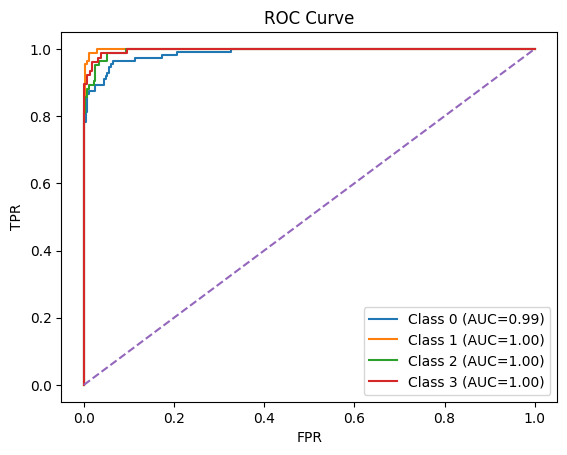

In [ ]:
# =========================
# ROC CURVE
# =========================
y_bin = label_binarize(y_true, classes=[0,1,2,3])

for i in range(4):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={auc(fpr,tpr):.2f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

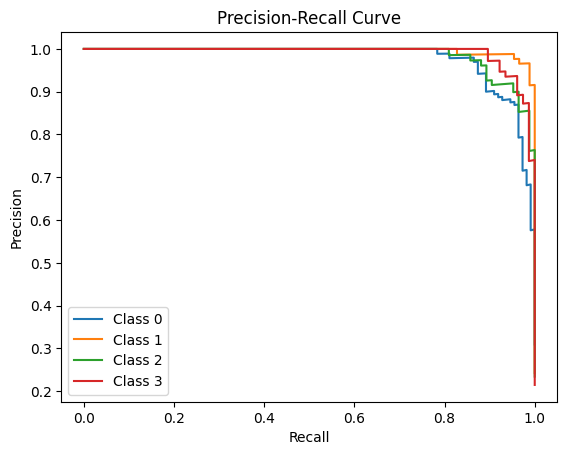

In [ ]:
# =========================
# PRECISION-RECALL
# =========================
for i in range(4):
    precision, recall, _ = precision_recall_curve(y_bin[:, i], y_prob[:, i])
    plt.plot(recall, precision, label=f"Class {i}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

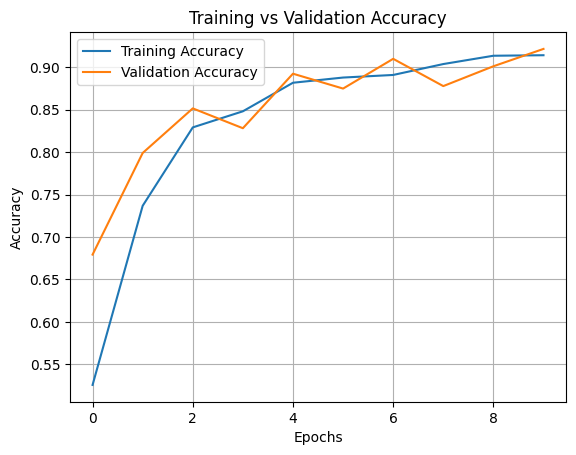

In [ ]:
# =========================
# ACCURACY GRAPH
# =========================
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')

plt.legend()
plt.grid()

plt.show()

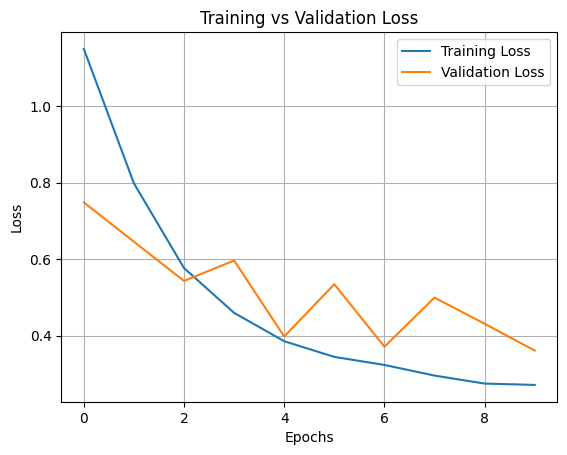

In [ ]:
# =========================
# LOSS GRAPH
# =========================
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')

plt.legend()
plt.grid()

plt.show()